<a href="https://colab.research.google.com/github/Jeyani11/ML_project_1/blob/main/SpamEmailDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk

# Dataset Loading using Panda

In [23]:
data = pd.read_csv('spam_ham_dataset.csv')
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [24]:
data.shape

(5171, 4)

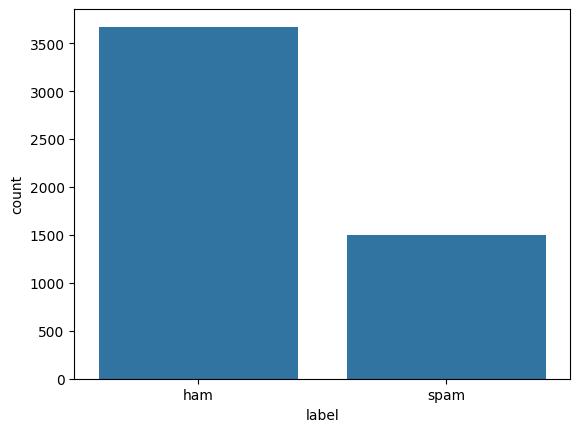

In [25]:
sns.countplot(x='label',data = data)
plt.show()

## Balance Dataset

In [26]:
ham = data[data['label'] == 'ham']
spam = data[data['label'] == 'spam']

# Match the number of Spam emails
ham_balanced = ham.sample(n=len(spam), random_state=42)

# Combine the dataset (combine the ham that is balanced and the spam)
combined_data = pd.concat([ham_balanced,spam]).reset_index(drop=True)




## Visualize the balanced dataset

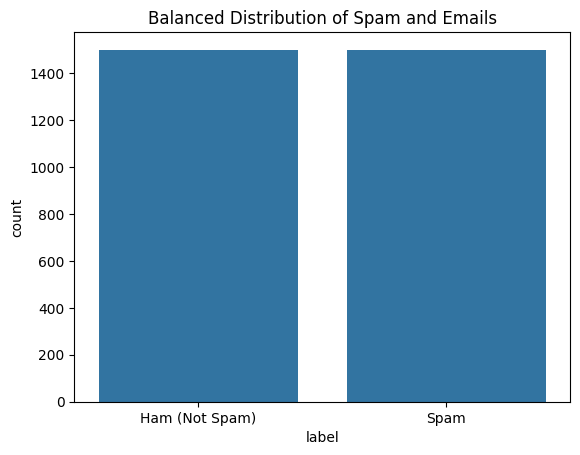

In [27]:
sns.countplot(x='label',data=combined_data)
plt.title("Balanced Distribution of Spam and Emails")
plt.xticks(ticks=[0,1], labels=['Ham (Not Spam)', 'Spam']) #get or set the x-axis ticks in a plot (allow to modify the labels and positions of the ticks)
plt.show()

## Clean the Text
- Stopwords Removal (remove the, is , a, can...)
- Punctuation Removal
- Stemming (Communication => Commun) Lemmatization (playing, v) => play

In [28]:
import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [29]:
combined_data['text'] = combined_data['text'].str.replace('Subject','')
combined_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


In [30]:
punctuation_list = string.punctuation
def remove_punctuation(text):
  mapping =  str.maketrans('','',punctuation_list)
  return text.translate(mapping)

combined_data['text'] = combined_data['text'].apply(lambda x: remove_punctuation(x))



In [31]:
combined_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0
